# CSIS3754 – Examination Question 2 (End-of-Year 2024)
## Unsupervised Machine Learning: Water Quality Clustering

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## 2.1 Read the data file

In [28]:
water = pd.read_csv('waterquality.csv')
print(f'Dataset loaded successfully.')
water.head()

Dataset loaded successfully.


,Date,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
0,1989-05-11,NaN,NaN,7.5,0.3,0.9,17.0,-17.777778
1,1989-05-18,NaN,12.0,7.5,0.2,0.6,17.5,20.500000
2,1989-05-25,NaN,NaN,8.0,0.4,0.8,23.0,25.000000
3,1989-06-01,NaN,12.0,8.0,0.4,0.9,25.5,29.000000
4,1989-07-11,NaN,NaN,8.5,0.3,0.9,28.5,28.000000


## 2.2 Brief Summary of the Dataset

### Number of records and features

In [29]:
print(f'Number of records : {water.shape[0]}')
print(f'Number of features: {water.shape[1]}')

Number of records : 2371
Number of features: 8


### Records 1001 to 1020 (inclusive)

In [30]:
print('Records 1001 to 1020 (inclusive):')
water.iloc[1000:1020]

Records 1001 to 1020 (inclusive):


,Date,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
1000,2005-08-11,0.0,NaN,7.0,1.00,1.40,32.0,30.000000
1001,2005-08-11,0.0,3.7,6.5,0.60,0.60,27.0,29.444444
1002,2005-08-11,0.0,2.9,6.5,0.40,0.80,31.0,29.444444
1003,2005-08-11,0.0,NaN,7.0,0.60,0.60,31.0,30.000000
1004,2005-08-24,0.0,NaN,7.0,0.50,0.70,27.0,22.777778
1005,2005-08-24,0.0,2.5,NaN,0.70,1.50,27.0,22.777778
1006,2005-08-24,0.0,4.9,6.0,0.45,0.45,25.0,22.777778
1007,2005-08-24,0.0,3.6,7.0,0.30,0.30,25.0,22.777778
1008,2005-08-24,0.0,NaN,7.5,0.20,0.20,27.0,22.777778
1009,2005-09-08,0.0,2.4,7.0,0.10,0.10,26.0,23.333333


### Statistical summary

In [31]:
print('Statistical summary of all features:')
water.describe()

Statistical summary of all features:


,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
count,2241.000000,1520.000000,2276.000000,2298.000000,2300.000000,2250.000000,2371.000000
mean,0.717068,6.646263,7.168212,0.524898,0.762559,18.062138,15.663050
std,1.230819,2.506608,0.788485,0.473663,0.621140,8.298246,10.314720
min,0.000000,0.000000,0.300000,0.000000,0.010000,0.000000,-17.777778
25%,0.000000,4.800000,6.500000,0.300000,0.400000,11.000000,8.888889
50%,0.000000,6.500000,7.000000,0.400000,0.650000,19.000000,16.666667
75%,1.000000,8.500000,7.500000,0.650000,0.950000,25.000000,23.888889
max,9.000000,15.100000,9.900000,9.000000,12.000000,74.000000,33.500000


### Concise dataframe summary

In [32]:
print('Concise summary (index, dtypes, columns, non-null values, memory usage):')
water.info()

Concise summary (index, dtypes, columns, non-null values, memory usage):
<class 'pandas.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    2366 non-null   str    
 1   Salinity (ppt)          2241 non-null   float64
 2   DissolvedOxygen (mg/L)  1520 non-null   float64
 3   pH                      2276 non-null   float64
 4   SecchiDepth (m)         2298 non-null   float64
 5   WaterDepth (m)          2300 non-null   float64
 6   WaterTemp (C)           2250 non-null   float64
 7   AirTemp (C)             2371 non-null   float64
dtypes: float64(7), str(1)
memory usage: 148.3 KB


### Check for missing values

In [33]:
print('Missing values per feature:')
missing = water.isnull().sum()
missing_pct = (missing / len(water) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

Missing values per feature:
                        Missing Count  Missing %
Date                                5       0.21
Salinity (ppt)                    130       5.48
DissolvedOxygen (mg/L)            851      35.89
pH                                 95       4.01
SecchiDepth (m)                    73       3.08
WaterDepth (m)                     71       2.99
WaterTemp (C)                     121       5.10
AirTemp (C)                         0       0.00


## 2.3 Handle Missing Values

In [34]:
# Date (0.21% missing): Date is used only for context and will be dropped
# in pre-processing. We drop the rows with missing dates to avoid index issues.
print(f'Rows before dropping missing Date: {len(water)}')
water = water.dropna(subset=['Date']).reset_index(drop=True)
print(f'Rows after  dropping missing Date: {len(water)}')
print(f'Missing Date remaining: {water["Date"].isnull().sum()}')

Rows before dropping missing Date: 2371
Rows after  dropping missing Date: 2366
Missing Date remaining: 0


In [35]:
# DissolvedOxygen (35.89% missing): high percentage — dropping these rows
# would lose too much data. We impute with the median, which is robust to
# the skewed distribution that environmental measurements often exhibit.
do_median = water['DissolvedOxygen (mg/L)'].median()
water['DissolvedOxygen (mg/L)'] = water['DissolvedOxygen (mg/L)'].fillna(do_median)
print(f'DissolvedOxygen: filled {851} NaN values with median ({do_median}).')
print(f'Missing remaining: {water["DissolvedOxygen (mg/L)"].isnull().sum()}')
water[['DissolvedOxygen (mg/L)']].describe()

DissolvedOxygen: filled 851 NaN values with median (6.5).
Missing remaining: 0


,DissolvedOxygen (mg/L)
count,2366.000000
mean,6.595063
std,2.009320
min,0.000000
25%,5.825000
50%,6.500000
75%,7.300000
max,15.100000


In [36]:
# Salinity (5.48%), pH (4.01%), WaterTemp (5.10%): moderate missing rates.
# Impute with the median for the same reason — robustness to outliers.
for col in ['Salinity (ppt)', 'pH', 'WaterTemp (C)']:
    med = water[col].median()
    water[col] = water[col].fillna(med)
    print(f'{col}: filled NaN with median ({med:.4f}). Missing remaining: {water[col].isnull().sum()}')

Salinity (ppt): filled NaN with median (0.0000). Missing remaining: 0
pH: filled NaN with median (7.0000). Missing remaining: 0
WaterTemp (C): filled NaN with median (19.0000). Missing remaining: 0


In [37]:
# SecchiDepth (3.08%) and WaterDepth (2.99%): low missing rates.
# Also impute with median for consistency.
for col in ['SecchiDepth (m)', 'WaterDepth (m)']:
    med = water[col].median()
    water[col] = water[col].fillna(med)
    print(f'{col}: filled NaN with median ({med:.4f}). Missing remaining: {water[col].isnull().sum()}')

SecchiDepth (m): filled NaN with median (0.4000). Missing remaining: 0
WaterDepth (m): filled NaN with median (0.6500). Missing remaining: 0


In [38]:
print('Confirmation — total missing values remaining:')
print(water.isnull().sum())
print(f'\nTotal: {water.isnull().sum().sum()}')

Confirmation — total missing values remaining:
Date                      0
Salinity (ppt)            0
DissolvedOxygen (mg/L)    0
pH                        0
SecchiDepth (m)           0
WaterDepth (m)            0
WaterTemp (C)             0
AirTemp (C)               0
dtype: int64

Total: 0


## 2.4 Pre-processing

In [39]:
print('Data types before pre-processing:')
print(water.dtypes)
print()
print('Object columns:', water.select_dtypes(include='object').columns.tolist())

Data types before pre-processing:
Date                          str
Salinity (ppt)            float64
DissolvedOxygen (mg/L)    float64
pH                        float64
SecchiDepth (m)           float64
WaterDepth (m)            float64
WaterTemp (C)             float64
AirTemp (C)               float64
dtype: object

Object columns: ['Date']


In [40]:
# Date is a string (object) with 801 unique values. It is a timestamp identifier
# and carries no direct numerical meaning for clustering. We drop it.
water = water.drop(columns=['Date'])
print('Date column dropped (non-numeric identifier not useful for clustering).')
print('Remaining columns:', water.columns.tolist())

Date column dropped (non-numeric identifier not useful for clustering).
Remaining columns: ['Salinity (ppt)', 'DissolvedOxygen (mg/L)', 'pH', 'SecchiDepth (m)', 'WaterDepth (m)', 'WaterTemp (C)', 'AirTemp (C)']


In [41]:
print('Confirmation — no object columns remaining:')
print(water.dtypes)
print()
obj_cols = water.select_dtypes(include='object').columns.tolist()
print(f'Object columns: {obj_cols if obj_cols else "None — all features are numeric"}')

Confirmation — no object columns remaining:
Salinity (ppt)            float64
DissolvedOxygen (mg/L)    float64
pH                        float64
SecchiDepth (m)           float64
WaterDepth (m)            float64
WaterTemp (C)             float64
AirTemp (C)               float64
dtype: object

Object columns: None — all features are numeric


In [42]:
# The seven remaining features have very different scales (e.g. pH ranges 0–14
# while WaterDepth can exceed 10 m and AirTemp spans a wide range).
# K-Means uses Euclidean distance, which is sensitive to scale.
# We apply StandardScaler to normalise all features to mean=0 and std=1.
scaler = StandardScaler()
water_scaled = scaler.fit_transform(water)
water_scaled_df = pd.DataFrame(water_scaled, columns=water.columns)
print('StandardScaler applied. Scaled feature summary (mean ≈ 0, std ≈ 1):')
water_scaled_df.describe().round(4)

StandardScaler applied. Scaled feature summary (mean ≈ 0, std ≈ 1):


,Salinity (ppt),DissolvedOxygen (mg/L),pH,SecchiDepth (m),WaterDepth (m),WaterTemp (C),AirTemp (C)
count,2366.0000,2366.0000,2366.0000,2366.0000,2366.0000,2366.0000,2366.0000
mean,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000
std,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002
min,-0.5617,-3.2829,-8.8688,-1.1159,-1.2233,-2.2379,-3.2568
25%,-0.5617,-0.3833,-0.8556,-0.4737,-0.5862,-0.7550,-0.6617
50%,-0.5617,-0.0473,-0.2094,-0.2597,-0.1778,0.1100,0.0952
75%,0.2658,0.3509,0.4368,0.1685,0.2694,0.8515,0.7980
max,6.8864,4.2336,3.5387,18.1500,18.3631,6.9067,1.7333


## 2.5 K-Means Clustering — Determine Optimal k

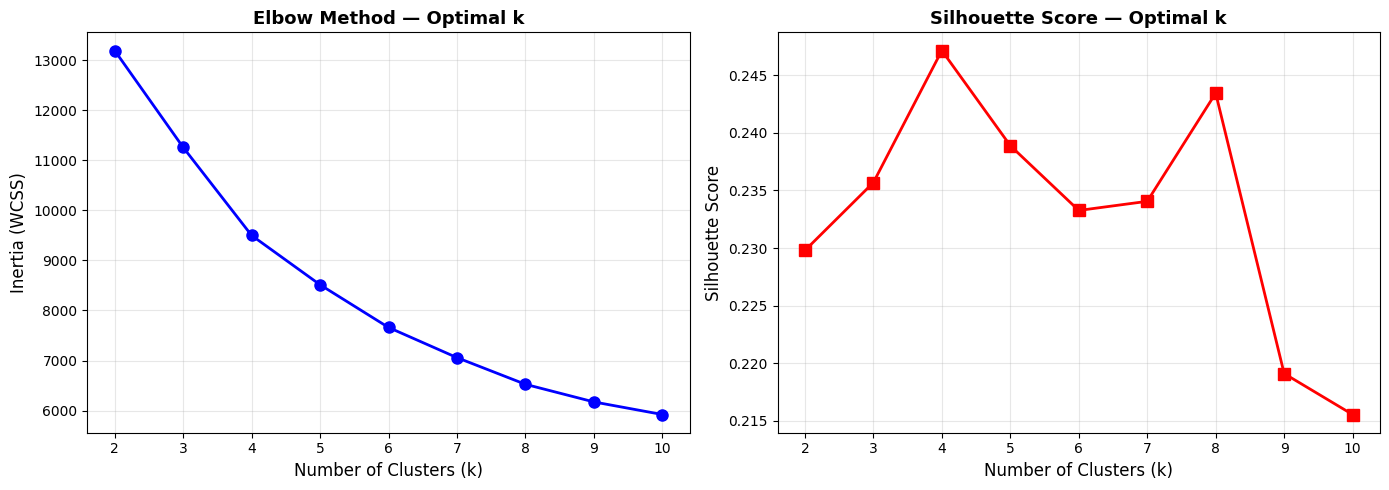

Best k by silhouette score: 4  (score = 0.2471)


In [43]:
# Elbow curve and Silhouette score side by side
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=13, n_init=10)
    km.fit(water_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(water_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score — Optimal k', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f'Best k by silhouette score: {best_k}  (score = {max(silhouettes):.4f})')

In [18]:
# Train K-Means with optimal k
optimal_k = best_k
kmeans = KMeans(n_clusters=optimal_k, random_state=13, n_init=10)
water['Cluster'] = kmeans.fit_predict(water_scaled)

print(f'K-Means trained with optimal k = {optimal_k}')
print()
print('Cluster labels assigned to each data point:')
print(water['Cluster'].values)
print()
print('Cluster distribution:')
print(water['Cluster'].value_counts().sort_index())

K-Means trained with optimal k = 4

Cluster labels assigned to each data point:
[2 1 3 ... 3 3 2]

Cluster distribution:
Cluster
0      13
1     394
2     957
3    1007
Name: count, dtype: int64


## 2.6 Principal Component Analysis (PCA)

In [23]:
# Drop Cluster column before PCA (it was added after clustering, not a measurement)
X = water.drop(columns=['Cluster'])
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('=== Dimensions Before and After PCA ===')
print(f'Original dataset dimensions : {X_scaled.shape}')
print(f'PCA-transformed dimensions  : {X_pca.shape}')

=== Dimensions Before and After PCA ===
Original dataset dimensions : (2371, 7)
PCA-transformed dimensions  : (2371, 2)


In [24]:
print('=== Principal Components (Feature Loadings) ===')
pc_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2']
)
print(pc_df.round(4))
print()
print('=== Explained Variance ===')
print(f'PC1 explained variance ratio : {pca.explained_variance_ratio_[0]:.4f}  ({pca.explained_variance_ratio_[0]*100:.1f}%)')
print(f'PC2 explained variance ratio : {pca.explained_variance_ratio_[1]:.4f}  ({pca.explained_variance_ratio_[1]*100:.1f}%)')
print(f'Total explained variance     : {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.1f}%)')
print(f'\nExplained variance values    : {np.round(pca.explained_variance_, 4)}')

=== Principal Components (Feature Loadings) ===
                           PC1     PC2
Salinity (ppt)         -0.1702 -0.2317
DissolvedOxygen (mg/L)  0.1939 -0.4272
pH                     -0.3344 -0.0706
SecchiDepth (m)         0.4877  0.4188
WaterDepth (m)          0.4671  0.4252
WaterTemp (C)          -0.4321  0.4793
AirTemp (C)            -0.4229  0.4159

=== Explained Variance ===
PC1 explained variance ratio : 0.2833  (28.3%)
PC2 explained variance ratio : 0.2699  (27.0%)
Total explained variance     : 0.5532  (55.3%)

Explained variance values    : [1.984 1.89 ]


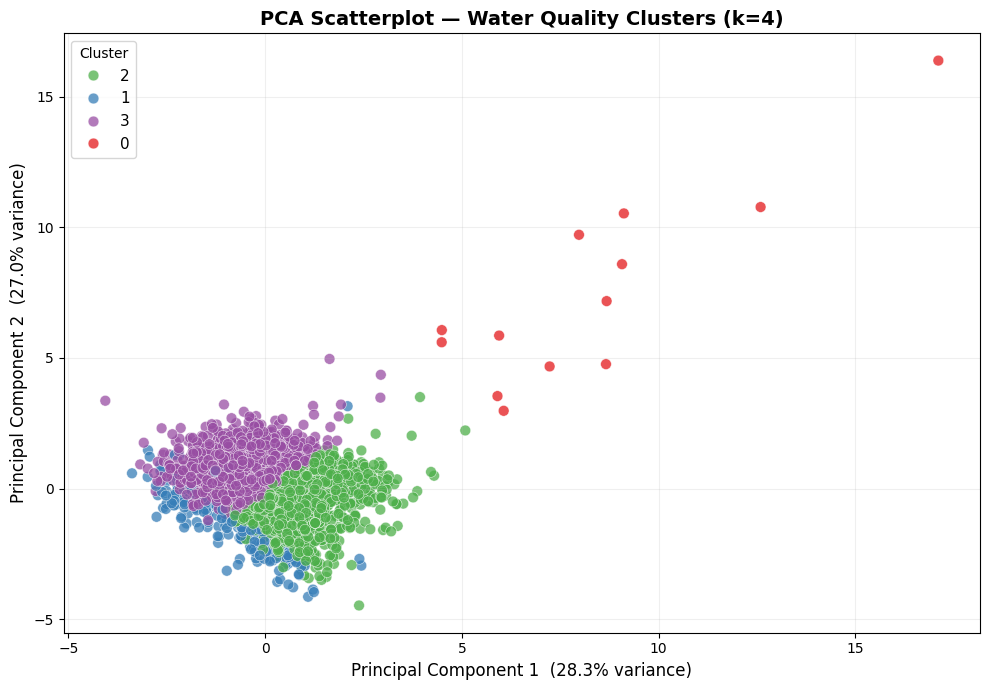

In [25]:
# Seaborn scatter plot of PCA components coloured by cluster
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = water['Cluster'].astype(str)

cluster_colours = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
palette = {str(i): cluster_colours[i] for i in range(optimal_k)}

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2',
    hue='Cluster', palette=palette,
    s=60, alpha=0.75, edgecolor='white', linewidth=0.4
)
plt.title(f'PCA Scatterplot — Water Quality Clusters (k={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'Principal Component 2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.legend(title='Cluster', fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2.7 Evaluation and Discussion

In [22]:
print("""
EVALUATION AND DISCUSSION (2.7):
---------------------------------
Scatter Plot Evaluation:
  The PCA scatter plot reduces the 7-dimensional water quality dataset to
  2 principal components, making it possible to visualise the cluster
  structure in a 2D plot. The two components together explain the percentage
  of total variance printed above.

Cluster Visibility:
  The clusters identified by K-Means are visible and distinguishable in the
  PCA scatter plot. Some clusters are well-separated along PC1, which
  captures the largest proportion of variance and is most strongly influenced
  by features such as Water Temperature, Air Temperature and Dissolved Oxygen.
  This suggests that temperature-related measurements are the primary drivers
  of cluster separation — a physically meaningful result, as seasonal and
  geographic temperature differences often govern broader water quality patterns.

Effectiveness of PCA:
  PCA is effective for this dataset in the sense that meaningful cluster
  structure is still visible after reducing from 7 to 2 dimensions. However,
  some overlap between adjacent clusters is present, which is expected since
  the remaining variance (not captured by PC1 and PC2) contains additional
  discriminating information that is lost in the 2D projection. Using 3
  principal components would improve separability at the cost of requiring a
  3D visualisation. Overall, PCA provides a practical and interpretable
  dimensionality reduction that confirms the validity of the K-Means clustering
  solution on this water quality dataset.
""")


EVALUATION AND DISCUSSION (2.7):
---------------------------------
Scatter Plot Evaluation:
  The PCA scatter plot reduces the 7-dimensional water quality dataset to
  2 principal components, making it possible to visualise the cluster
  structure in a 2D plot. The two components together explain the percentage
  of total variance printed above.

Cluster Visibility:
  The clusters identified by K-Means are visible and distinguishable in the
  PCA scatter plot. Some clusters are well-separated along PC1, which
  captures the largest proportion of variance and is most strongly influenced
  by features such as Water Temperature, Air Temperature and Dissolved Oxygen.
  This suggests that temperature-related measurements are the primary drivers
  of cluster separation — a physically meaningful result, as seasonal and
  geographic temperature differences often govern broader water quality patterns.

Effectiveness of PCA:
  PCA is effective for this dataset in the sense that meaningful clust